# Função Logarítmica

**Módulo:** 02 – Logaritmos

**Pré-requisitos:** [`0203a_logaritmos.ipynb`](0203a_logaritmos.ipynb) (definição e propriedades de logaritmo), [`0202a_funcao_exponencial.ipynb`](0202a_funcao_exponencial.ipynb) (função exponencial, domínio/imagem/gráfico) e [`0112a_transformacoes_composta_e_inversa.ipynb`](../01_conjuntos_e_funcoes/0112a_transformacoes_composta_e_inversa.ipynb) (função composta e inversa)

**Objetivos de aprendizagem:**
- Definir a função logarítmica, seu domínio e imagem, e reconhecer os dois comportamentos possíveis (crescente/decrescente).
- Demonstrar e visualizar que a função logarítmica é a inversa da função exponencial, e usar essa relação para esboçar gráficos.
- Comparar a "velocidade" do crescimento logarítmico com o linear e o exponencial.
- Reconhecer escalas logarítmicas do mundo real (Richter, decibéis, pH) e interpretar seus valores.

**Tempo estimado:** 80 a 100 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/02_logaritmos/0204a_funcao_logaritmica.ipynb)


## Que cara tem o inverso da exponencial?

No notebook anterior, definimos o logaritmo como a resposta à pergunta "a que expoente elevo a base para chegar nesse número?" — e resolvemos, de uma vez por todas, a equação 2ˣ = 10 que ficou em aberto desde `0202a_funcao_exponencial`.

Mas até aqui tratamos o logaritmo como uma **operação** (calcular log_a(b) para valores específicos), não como uma **função**. E se, em vez de calcular um logaritmo de cada vez, perguntarmos: qual é o comportamento de x = log_a(y) conforme y varia?

**Antes de continuar, arrisque um palpite.** Se o logaritmo desfaz a exponencial, o que você espera que o gráfico dessa nova função pareça, comparado ao gráfico de aˣ?

Spoiler: a resposta vai ser, literalmente, um espelho.

📖 **Leitura complementar:** [Logaritmos](https://pt.wikipedia.org/wiki/Logaritmos)


In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    '''Aplica o estilo Nord padrão a um eixo do matplotlib.'''
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


## 1. Definição e Domínio da Função Logarítmica

📌 **Definição formal:**

$$f(x) = \log_a(x), \quad \text{com } a > 0,\ a \neq 1,\ x > 0$$

O **domínio** é ℝ*₊ (só os reais positivos) — a mesma condição de existência do logaritmando, vista no notebook anterior (`0203a_logaritmos`): log_a(x) só existe para x > 0.


In [2]:
# Implementando f(x) = log_a(x) para algumas bases e calculando para vários x
def funcao_logaritmica(a: float, x: float) -> float:
    '''Calcula f(x) = log_a(x), com a > 0, a != 1 e x > 0.'''
    return math.log(x, a)


bases_teste = [2, 10, 0.5]
xs_teste = [0.1, 0.5, 1, 2, 8, 100]

for a in bases_teste:
    valores = [round(funcao_logaritmica(a, x), 4) for x in xs_teste]
    print(f"a = {a:>4g}:", dict(zip(xs_teste, valores)))

# Testando um x negativo, para confirmar que dá erro (como esperado)
print("\ntentando f(-5) com a=2:")
try:
    funcao_logaritmica(2, -5)
except ValueError as erro:
    print("  ValueError:", erro)


a =    2: {0.1: -3.3219, 0.5: -1.0, 1: 0.0, 2: 1.0, 8: 3.0, 100: 6.6439}
a =   10: {0.1: -1.0, 0.5: -0.301, 1: 0.0, 2: 0.301, 8: 0.9031, 100: 2.0}
a =  0.5: {0.1: 3.3219, 0.5: 1.0, 1: -0.0, 2: -1.0, 8: -3.0, 100: -6.6439}

tentando f(-5) com a=2:
  ValueError: math domain error


**Pergunta de checagem:** Por que o domínio da função logarítmica é só os números positivos, enquanto o domínio da exponencial (notebook anterior) era todo ℝ?

🎯 **Aplicação prática:** qualquer processo cujo "tamanho" varia numa faixa tão ampla que preferimos medir em escala logarítmica (terremotos, som, acidez) usa essa função — prévia dos blocos 6 e 7.


## 2. Função Logarítmica como Inversa da Exponencial

📌 **Definição formal:** as consequências diretas da definição de logaritmo, já vistas em `0203a_logaritmos`,

$$a^{\log_a(x)} = x \qquad \log_a(a^x) = x$$

dizem exatamente que log_a(x) **desfaz** aˣ, e vice-versa: as duas funções são **inversas** uma da outra.

📎 **Conexão:** como consequência (vista em `0112a_transformacoes_composta_e_inversa`), os gráficos de duas funções inversas são **simétricos em relação à reta y = x** — o gráfico de uma é o reflexo do gráfico da outra nesse "espelho".


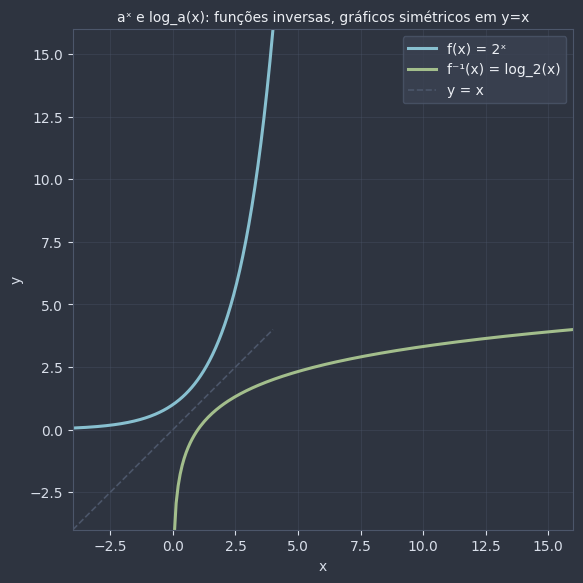

In [3]:
# Plotando a^x e log_a(x) no mesmo plano, junto com a reta y=x,
# para evidenciar a simetria (espelho) entre as duas curvas
a = 2
xs_exp = np.linspace(-4, 4, 200)
xs_log = np.linspace(0.05, 16, 200)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)

ax.plot(xs_exp, a**xs_exp, color=COR_PONTO, linewidth=2.2, label=f"f(x) = {a}ˣ")
ax.plot(xs_log, np.log(xs_log) / np.log(a), color=COR_DESTAQUE, linewidth=2.2, label=f"f⁻¹(x) = log_{a}(x)")
ax.plot(xs_exp, xs_exp, color=NORD_LINHA, linewidth=1.2, linestyle="--", label="y = x")

ax.set_xlim(-4, 16)
ax.set_ylim(-4, 16)
ax.set_aspect("equal")
ax.set_xlabel("x", color=NORD_TEXTO_SEC)
ax.set_ylabel("y", color=NORD_TEXTO_SEC)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=10)
ax.set_title("aˣ e log_a(x): funções inversas, gráficos simétricos em y=x", color=NORD_TEXTO, fontsize=10)
plt.show()


🕹️ **Widget interativo:** escolha a base a e observe as duas curvas espelhadas se atualizando em tempo real, junto com a reta y=x.


In [ ]:
def explorar_inversa(a: float) -> None:
    xs_exp = np.linspace(-4, 4, 200)
    xs_log = np.linspace(0.02, 16, 200)

    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs_exp, a**xs_exp, color=COR_PONTO, linewidth=2.2, label=f"{a:g}ˣ")
    ax.plot(xs_log, np.log(xs_log) / np.log(a), color=COR_DESTAQUE, linewidth=2.2, label=f"log_{a:g}(x)")
    ax.plot(xs_exp, xs_exp, color=NORD_LINHA, linewidth=1.2, linestyle="--", label="y = x")
    ax.set_xlim(-4, 16)
    ax.set_ylim(-4, 16)
    ax.set_aspect("equal")
    ax.set_xlabel("x", color=NORD_TEXTO_SEC)
    ax.set_ylabel("y", color=NORD_TEXTO_SEC)
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=9)
    plt.show()


widgets.interact(
    explorar_inversa,
    a=widgets.FloatSlider(value=2.0, min=1.1, max=5.0, step=0.1, description="a:"),
)


interactive(children=(FloatSlider(value=2.0, description='a:', max=5.0, min=1.1), Output()), _dom_classes=('wi…

<function __main__.explorar_inversa(a: float) -> None>

**Pergunta de checagem:** Se o ponto (2, 8) está no gráfico de 2ˣ, que ponto simétrico deve estar no gráfico de log₂(x)?

## 3. Propriedades, Imagem e Gráfico

📌 **Definição formal:** a **imagem** da função logarítmica é ℝ (todos os reais) — diferente da exponencial, cuja imagem era só os positivos.

Assim como a exponencial, existem dois comportamentos possíveis, dependendo da base:
- **a > 1:** f é **crescente**.
- **0 < a < 1:** f é **decrescente**.

💡 **Dica:** duas características do gráfico valem para qualquer base válida:
- Ele sempre passa pelo ponto **(1, 0)**, pois log_a(1) = 0.
- Ele nunca toca o eixo y — o eixo y é uma **assíntota vertical** (x = 0).


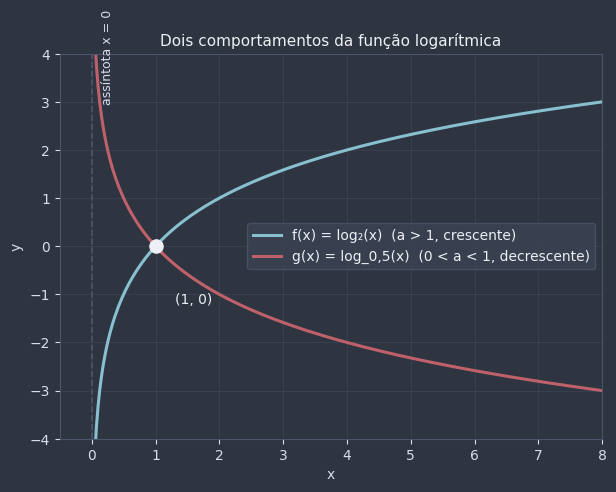

In [5]:
# Plotando duas funções logarítmicas: uma com a > 1 (crescente)
# e outra com 0 < a < 1 (decrescente), destacando (1, 0) e a assíntota
xs = np.linspace(0.02, 8, 300)

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)

ax.plot(xs, np.log2(xs), color=COR_PONTO, linewidth=2.2, label="f(x) = log₂(x)  (a > 1, crescente)")
ax.plot(xs, np.log(xs) / np.log(0.5), color=COR_ALERTA, linewidth=2.2, label="g(x) = log_0,5(x)  (0 < a < 1, decrescente)")

ax.scatter([1], [0], s=90, color=NORD_TEXTO, zorder=5)
ax.annotate("(1, 0)", xy=(1, 0), xytext=(1.3, -1.2), color=NORD_TEXTO, fontsize=10)
ax.axvline(0, color=NORD_LINHA, linewidth=1.2, linestyle="--")
ax.text(0.15, 3, "assíntota x = 0", color=NORD_TEXTO_SEC, fontsize=9, rotation=90)

ax.set_xlabel("x", color=NORD_TEXTO_SEC)
ax.set_ylabel("y", color=NORD_TEXTO_SEC)
ax.set_xlim(-0.5, 8)
ax.set_ylim(-4, 4)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=10)
ax.set_title("Dois comportamentos da função logarítmica", color=NORD_TEXTO, fontsize=11)
plt.show()


🕹️ **Widget interativo:** mexa no slider da base a e observe o gráfico mudar de crescente para decrescente conforme a cruza o valor 1.


In [6]:
def explorar_base_log(a: float) -> None:
    if abs(a - 1) < 1e-9:
        print("base a = 1 não é permitida -- log_1(x) não está definido.")
        return

    xs = np.linspace(0.02, 8, 300)
    ys = np.log(xs) / np.log(a)

    fig, ax = plt.subplots(figsize=(7, 4.8))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    cor = COR_PONTO if a > 1 else COR_ALERTA
    comportamento = "crescente" if a > 1 else "decrescente"
    ax.plot(xs, ys, color=cor, linewidth=2.2)
    ax.scatter([1], [0], s=90, color=NORD_TEXTO, zorder=5)
    ax.axvline(0, color=NORD_LINHA, linewidth=1.2, linestyle="--")
    ax.set_xlabel("x", color=NORD_TEXTO_SEC)
    ax.set_ylabel(f"log_{a:g}(x)", color=NORD_TEXTO_SEC)
    ax.set_xlim(-0.5, 8)
    ax.set_ylim(-4, 4)
    ax.set_title(f"f(x) = log_{a:g}(x)  —  {comportamento}", color=cor, fontsize=11)
    plt.show()


widgets.interact(
    explorar_base_log,
    a=widgets.FloatSlider(value=2.0, min=0.1, max=5.0, step=0.1, description="a:"),
)


interactive(children=(FloatSlider(value=2.0, description='a:', max=5.0, min=0.1), Output()), _dom_classes=('wi…

<function __main__.explorar_base_log(a: float) -> None>

**Pergunta de checagem:** Por que o gráfico de log_a(x) nunca toca o eixo y, por mais que x se aproxime de zero?

🎯 **Aplicação prática:** o número de dígitos de um número inteiro cresce logaritmicamente com seu valor (aproximadamente ⌊log₁₀(n)⌋+1 dígitos) — por isso números "gigantes" ainda têm poucos dígitos.

## 4. Transformações do Gráfico

💡 **Dica:** a partir de f(x) = log_a(x), as mesmas transformações vistas para a exponencial (notebook `0202a_funcao_exponencial`) produzem efeitos análogos:

| Transformação | Efeito |
|---|---|
| f(x) + k | desloca o gráfico **verticalmente** |
| f(x + k) | desloca o gráfico **horizontalmente** (a assíntota vai de x=0 para x=-k) |
| c · f(x) | **escala** o gráfico verticalmente (c > 1 estica, 0 < c < 1 comprime) |


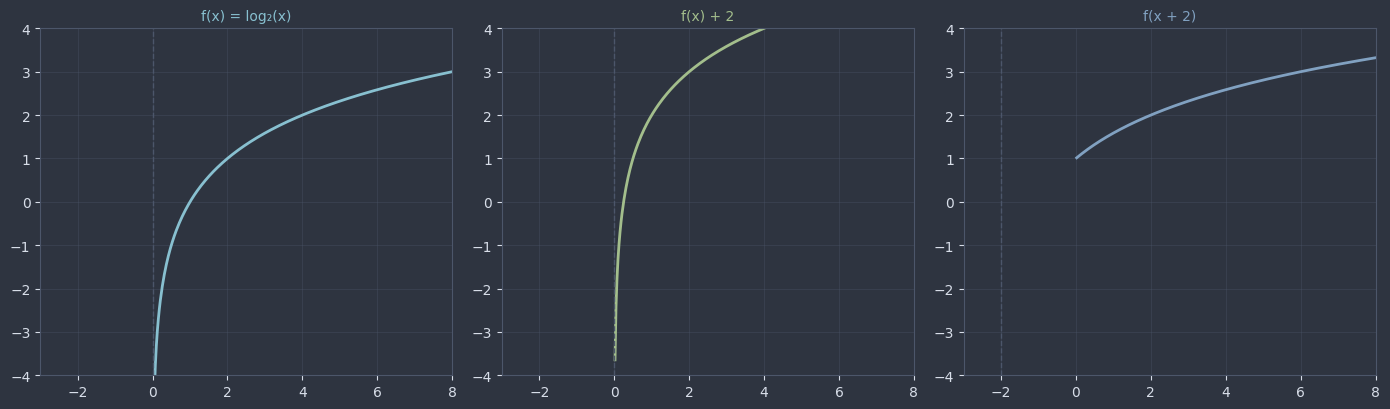

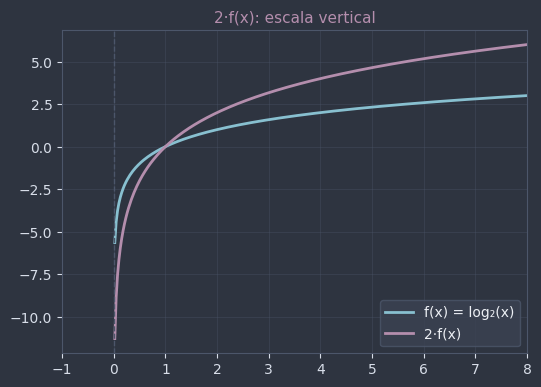

In [7]:
# Comparando f(x) = log_a(x) com suas variações lado a lado
xs = np.linspace(0.02, 8, 300)
k, c = 2, 2

fig, axs = plt.subplots(1, 3, figsize=(14, 4.2))
fig.patch.set_facecolor(NORD_FUNDO)

configuracoes = [
    (np.log2(xs), "f(x) = log₂(x)", COR_PONTO, 0),
    (np.log2(xs) + k, f"f(x) + {k}", COR_DESTAQUE, 0),
    (np.log2(xs + k), f"f(x + {k})", COR_SECUNDARIA, -k),
]

for ax, (ys, titulo, cor, assintota) in zip(axs, configuracoes):
    estilizar_eixo(ax)
    ax.plot(xs, ys, color=cor, linewidth=2)
    ax.axvline(assintota, color=NORD_LINHA, linewidth=1, linestyle="--")
    ax.set_title(titulo, color=cor, fontsize=10)
    ax.set_xlim(-3, 8)
    ax.set_ylim(-4, 4)

plt.tight_layout()
plt.show()

# c*f(x) em destaque separado, por afetar a escala e não a posição da assíntota
fig, ax = plt.subplots(figsize=(6, 4.2))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(xs, np.log2(xs), color=COR_PONTO, linewidth=2, label="f(x) = log₂(x)")
ax.plot(xs, c * np.log2(xs), color=COR_EXTRA, linewidth=2, label=f"{c}·f(x)")
ax.axvline(0, color=NORD_LINHA, linewidth=1, linestyle="--")
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA)
ax.set_xlim(-1, 8)
ax.set_title(f"{c}·f(x): escala vertical", color=COR_EXTRA, fontsize=11)
plt.show()


🕹️ **Widget interativo:** mexa nos sliders de k (deslocamento) e c (escala) e observe o gráfico de log₂(x) se transformando em tempo real.


In [ ]:
def explorar_transformacoes_log(k: float, c: float) -> None:
    xs_original = np.linspace(0.02, 8, 300)
    xs = np.linspace(-7.9, 8, 400)
    xs_validos = xs[xs + k > 0]

    fig, ax = plt.subplots(figsize=(7, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs_original, np.log2(xs_original), color=NORD_LINHA, linewidth=1.5, linestyle=":", label="f(x) = log₂(x) (original)")
    ax.plot(xs_validos, c * np.log2(xs_validos + k), color=COR_DESTAQUE, linewidth=2.2, label=f"{c:g}·f(x + {k:g})")
    ax.axvline(-k, color=COR_ALERTA, linewidth=1, linestyle="--", label=f"assíntota x = {-k:g}")

    ax.set_xlabel("x", color=NORD_TEXTO_SEC)
    ax.set_ylabel("y", color=NORD_TEXTO_SEC)
    ax.set_xlim(-8, 8)
    ax.set_ylim(-6, 6)
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=9)
    plt.show()


widgets.interact(
    explorar_transformacoes_log,
    k=widgets.FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.5, description="k:"),
    c=widgets.FloatSlider(value=1.0, min=0.2, max=3.0, step=0.1, description="c:"),
)


interactive(children=(FloatSlider(value=0.0, description='k:', max=5.0, min=-5.0, step=0.5), FloatSlider(value…

<function __main__.explorar_transformacoes_log(k: float, c: float) -> None>

**Pergunta de checagem:** O que acontece com a assíntota vertical quando deslocamos horizontalmente para log_a(x+k)?

🎯 **Aplicação prática:** em gráficos científicos, é comum usar log(x+1) em vez de log(x) para evitar problemas quando os dados incluem o valor zero.

📖 **Leitura complementar:** [Escala logarítmica](https://pt.wikipedia.org/wiki/Escala_logar%C3%ADtmica)


## 5. Comparação de Crescimento: Logarítmico vs Linear vs Exponencial

⚠️ **Erro comum:** achar que, por crescer para sempre sem limite superior, o logaritmo cresce "rápido" como a exponencial.

Ordenando os três tipos de crescimento por velocidade, do mais lento ao mais rápido:

$$\text{logarítmico} \ll \text{linear} \ll \text{exponencial}$$

O crescimento logarítmico é, em certo sentido, o "oposto" do exponencial em termos de velocidade — mesmo assim, ele nunca para de crescer.


,x,log(x),x (linear),e^x
0,1,0.00,1,2.72e+00
1,5,1.61,5,1.48e+02
2,10,2.30,10,2.20e+04
3,15,2.71,15,3.27e+06
4,20,3.00,20,4.85e+08
5,25,3.22,25,7.20e+10


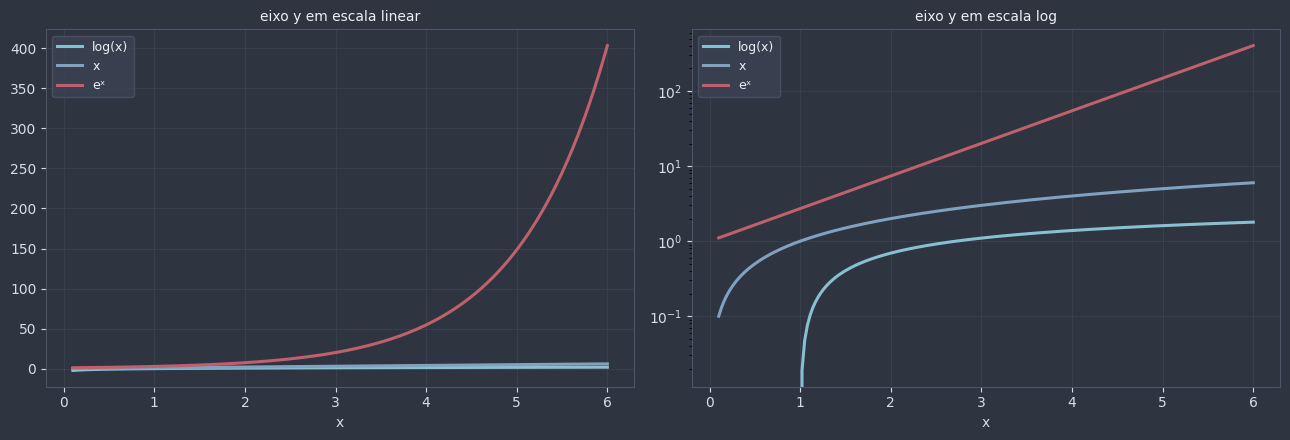

In [9]:
# Comparando numérica e graficamente log(x), x e e^x para valores crescentes de x
xs_tabela = np.array([1, 5, 10, 15, 20, 25])

tabela_crescimento = pd.DataFrame(
    {
        "x": xs_tabela,
        "log(x)": np.round(np.log(xs_tabela), 2),
        "x (linear)": xs_tabela,
        "e^x": [f"{math.exp(x):.2e}" for x in xs_tabela],
    }
)
display(tabela_crescimento)

fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)

xs_plot = np.linspace(0.1, 6, 200)
for ax, escala in zip(axs, ["linear", "log"]):
    estilizar_eixo(ax)
    ax.plot(xs_plot, np.log(xs_plot), color=COR_PONTO, linewidth=2.2, label="log(x)")
    ax.plot(xs_plot, xs_plot, color=COR_SECUNDARIA, linewidth=2.2, label="x")
    ax.plot(xs_plot, np.exp(xs_plot), color=COR_ALERTA, linewidth=2.2, label="eˣ")
    ax.set_yscale(escala)
    ax.set_title(f"eixo y em escala {escala}", color=NORD_TEXTO, fontsize=10)
    ax.set_xlabel("x", color=NORD_TEXTO_SEC)
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=9)

plt.tight_layout()
plt.show()


🕹️ **Widget interativo:** as três curvas juntas, com controle de escala (linear/log) no eixo y para facilitar a comparação.


In [ ]:
def comparar_crescimentos(x_max: float, escala: str) -> None:
    xs = np.linspace(0.1, x_max, 300)

    fig, ax = plt.subplots(figsize=(7.5, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs, np.log(xs), color=COR_PONTO, linewidth=2.2, label="log(x)")
    ax.plot(xs, xs, color=COR_SECUNDARIA, linewidth=2.2, label="x")
    ax.plot(xs, np.exp(xs), color=COR_ALERTA, linewidth=2.2, label="eˣ")
    ax.set_yscale(escala)
    ax.set_xlabel("x", color=NORD_TEXTO_SEC)
    ax.set_ylabel("y", color=NORD_TEXTO_SEC)
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=9)
    plt.show()


widgets.interact(
    comparar_crescimentos,
    x_max=widgets.FloatSlider(value=6.0, min=2.0, max=15.0, step=0.5, description="x máximo:"),
    escala=widgets.Dropdown(options=["linear", "log"], value="linear", description="escala y:"),
)


interactive(children=(FloatSlider(value=6.0, description='x máximo:', max=15.0, min=2.0, step=0.5), Dropdown(d…

<function __main__.comparar_crescimentos(x_max: float, escala: str) -> None>

**Pergunta de checagem:** por que, apesar de o logaritmo crescer para sempre (sem limite superior), ele é considerado um crescimento "lento"?

🎯 **Aplicação prática:** complexidade de algoritmos em ciência da computação — uma busca binária é O(log n), muito mais eficiente que uma busca linear O(n) para conjuntos grandes de dados.


## 6. Aplicações: Escala Richter

📌 **Definição formal:** a magnitude M de um terremoto está relacionada à amplitude sísmica A numa escala logarítmica de base 10 — cada unidade a mais na magnitude corresponde a uma amplitude **10 vezes maior**:

$$M = \log_{10}\left(\frac{A}{A_0}\right) \quad \iff \quad \frac{A}{A_0} = 10^M$$


In [11]:
# Quantas vezes mais forte é um terremoto de magnitude 7 comparado a um de magnitude 5?
magnitude_1, magnitude_2 = 7, 5
razao_amplitude = 10 ** (magnitude_1 - magnitude_2)

print(f"diferença de magnitude: {magnitude_1} - {magnitude_2} = {magnitude_1 - magnitude_2}")
print(f"razão de amplitude: 10^{magnitude_1 - magnitude_2} = {razao_amplitude}x mais forte")


diferença de magnitude: 7 - 5 = 2
razão de amplitude: 10^2 = 100x mais forte


🕹️ **Widget interativo:** mexa no slider de magnitude e observe a amplitude relativa crescendo exponencialmente conforme a magnitude aumenta linearmente.


In [ ]:
def explorar_richter(magnitude: float) -> None:
    magnitude_referencia = 0
    razao = 10 ** (magnitude - magnitude_referencia)

    magnitudes = np.linspace(0, 9, 200)
    razoes = 10 ** (magnitudes - magnitude_referencia)

    fig, ax = plt.subplots(figsize=(7, 4.8))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(magnitudes, razoes, color=COR_PONTO, linewidth=2.2)
    ax.set_yscale("log")
    ax.scatter([magnitude], [razao], s=100, color=COR_DESTAQUE, zorder=5)
    ax.set_xlabel("magnitude Richter", color=NORD_TEXTO_SEC)
    ax.set_ylabel("amplitude relativa (escala log)", color=NORD_TEXTO_SEC)
    ax.set_title(f"magnitude {magnitude:g}  →  amplitude {razao:,.0f}x maior que a referência", color=COR_DESTAQUE, fontsize=10)
    plt.show()


widgets.interact(
    explorar_richter,
    magnitude=widgets.FloatSlider(value=5.0, min=0.0, max=9.0, step=0.5, description="magnitude:"),
)


interactive(children=(FloatSlider(value=5.0, description='magnitude:', max=9.0, step=0.5), Output()), _dom_cla…

<function __main__.explorar_richter(magnitude: float) -> None>

**Pergunta de checagem:** por que os sismólogos preferem uma escala logarítmica para medir terremotos, em vez de uma escala linear direta de amplitude?

📖 **Leitura complementar:** [Escala de Richter](https://pt.wikipedia.org/wiki/Escala_de_Richter)


## 7. Aplicações: Decibéis e pH

📌 **Definição formal:** decibéis (intensidade sonora) e pH (acidez) são outras escalas logarítmicas do cotidiano:

$$dB = 10 \cdot \log_{10}\left(\frac{I}{I_0}\right) \qquad pH = -\log_{10}[H^+]$$


In [13]:
# Diferença de intensidade sonora entre dois ambientes, dados seus valores em decibéis
db_1, db_2 = 70, 40  # ex.: rua movimentada vs biblioteca
razao_intensidade = 10 ** ((db_1 - db_2) / 10)
print(f"{db_1}dB é {razao_intensidade:g}x mais intenso que {db_2}dB")

# Concentração de íons H+ a partir de um valor de pH
ph = 3.0  # ex.: suco de limão
concentracao_h = 10**-ph
print(f"\npH = {ph:g}  ->  [H+] = 10^-{ph:g} = {concentracao_h:.2e} mol/L")


70dB é 1000x mais intenso que 40dB

pH = 3  ->  [H+] = 10^-3 = 1.00e-03 mol/L


🕹️ **Widget interativo:** um "medidor" — escolha dB ou pH e mexa no slider, e veja a grandeza física correspondente crescendo/diminuindo exponencialmente conforme o valor na escala muda.


In [14]:
def medidor_log(grandeza: str, valor: float) -> None:
    if grandeza == "decibéis (dB)":
        intensidade_relativa = 10 ** (valor / 10)
        print(f"{valor:g} dB  ->  intensidade relativa I/I0 = 10^({valor:g}/10) = {intensidade_relativa:,.2f}")
    else:
        concentracao_h = 10**-valor
        print(f"pH = {valor:g}  ->  [H+] = 10^-{valor:g} = {concentracao_h:.2e} mol/L")


widgets.interact(
    medidor_log,
    grandeza=widgets.Dropdown(options=["decibéis (dB)", "pH"], value="decibéis (dB)", description="grandeza:"),
    valor=widgets.FloatSlider(value=60.0, min=0.0, max=140.0, step=1.0, description="valor:"),
)


interactive(children=(Dropdown(description='grandeza:', options=('decibéis (dB)', 'pH'), value='decibéis (dB)'…

<function __main__.medidor_log(grandeza: str, valor: float) -> None>

**Pergunta de checagem:** se o pH de uma solução cai de 7 para 5, quantas vezes mais ácida ela ficou?

📖 **Leitura complementar:** [Decibel](https://pt.wikipedia.org/wiki/Decibel) · [pH (potencial hidrogeniônico)](https://pt.wikipedia.org/wiki/Potencial_hidrogeni%C3%B4nico)


## 8. Gancho final: Rumo às Equações e Inequações

📎 **Conexão:** agora que temos as duas funções (exponencial e logarítmica) e sabemos que são inversas uma da outra, podemos resolver **qualquer** equação exponencial — não só as redutíveis a uma base comum — usando logaritmo. O mesmo vale para inequações.


In [15]:
# Finalmente resolvendo por completo o 2^x = 10, que ficou em aberto
# desde 0202a_funcao_exponencial
x = math.log(10, 2)
print(f"2^x = 10  ->  x = log_2(10) = {x:.4f}")
print(f"conferindo: 2^{x:.4f} = {2**x:.4f}  (bate com 10)")
print("\nciclo fechado: começamos sem saber esboçar x em função de aˣ, e agora sabemos")
print("definir essa função, esboçar seu gráfico e usá-la para resolver qualquer equação exponencial.")


2^x = 10  ->  x = log_2(10) = 3.3219
conferindo: 2^3.3219 = 10.0000  (bate com 10)

ciclo fechado: começamos sem saber esboçar x em função de aˣ, e agora sabemos
definir essa função, esboçar seu gráfico e usá-la para resolver qualquer equação exponencial.


**Pergunta de checagem:** agora que sabemos usar o logaritmo para "isolar" um expoente, que tipos de equações mais complexas você imagina que conseguiremos resolver a partir de agora?


## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| f(x) = log_a(x) | a>0, a≠1, x>0; domínio = ℝ*₊; imagem = ℝ |
| Inversa da exponencial | log_a(x) desfaz aˣ; gráficos simétricos em relação à reta y=x |
| Gráfico | sempre passa por (1,0); assíntota vertical em x=0; nunca toca o eixo y |
| Comportamento | a > 1 → crescente \| 0 < a < 1 → decrescente |
| Transformações | f(x)+k desloca vertical \| f(x+k) desloca horizontal (assíntota em x=-k) \| c·f(x) escala vertical |
| Velocidade de crescimento | logarítmico < linear < exponencial |
| Richter | M = log10(A/A0); cada unidade a mais = amplitude 10x maior |
| dB e pH | dB = 10·log10(I/I0) \| pH = -log10[H+] |


## Exercícios

**Básico**
1. Determine o domínio e a imagem de f(x)=log_3(x) e g(x)=log_(1/4)(x), e classifique cada uma como crescente ou decrescente.
2. Calcule f(1) para uma função logarítmica qualquer e diga por qual ponto fixo o gráfico de qualquer função logarítmica passa, além da equação da assíntota vertical.

**Intermediário**
3. Use a relação de função inversa para descobrir pontos do gráfico de log_a(x) a partir de pontos conhecidos do gráfico de aˣ.
4. Dada uma transformação log_a(x+k), determine o novo domínio e a nova assíntota vertical.

**Desafio**
5. Um problema real envolvendo escala Richter: calcule a razão de amplitude entre dois terremotos a partir da diferença de magnitude.

Gabarito completo com resolução passo a passo em [`0204b_funcao_logaritmica_gabarito.ipynb`](0204b_funcao_logaritmica_gabarito.ipynb) — tente resolver sozinho antes de olhar.


### Básico

In [ ]:
# Exercício Básico 1: para f(x) = log_3(x) e g(x) = log_(1/4)(x), determine:
# - o domínio de cada uma (como string, "R*+")
# - a imagem de cada uma (como string, "R")
# - se cada uma é crescente ou decrescente (como string, "crescente" ou "decrescente")
dominio_f = ...
imagem_f = ...
comportamento_f = ...

dominio_g = ...
imagem_g = ...
comportamento_g = ...

print(dominio_f, imagem_f, comportamento_f)
print(dominio_g, imagem_g, comportamento_g)


In [ ]:
# Verificação
assert dominio_f == "R*+" and dominio_g == "R*+", (
    "Tente de novo, revise: o domínio de qualquer função logarítmica é R*+ "
    "(seção 1 - Definição e Domínio)."
)
assert imagem_f == "R" and imagem_g == "R", (
    "Tente de novo, revise: a imagem de qualquer função logarítmica é R "
    "(seção 3 - Propriedades, Imagem e Gráfico)."
)
assert comportamento_f == "crescente", (
    "Tente de novo, revise: f(x)=log_3(x) tem base 3 > 1, logo é crescente "
    "(seção 3 - Propriedades, Imagem e Gráfico)."
)
assert comportamento_g == "decrescente", (
    "Tente de novo, revise: g(x)=log_(1/4)(x) tem base entre 0 e 1, logo é decrescente "
    "(seção 3 - Propriedades, Imagem e Gráfico)."
)
print("Certo!")


In [ ]:
# Exercício Básico 2: para f(x) = log_5(x), calcule f(1) e diga por qual ponto
# fixo o gráfico de QUALQUER função logarítmica passa (como tupla (x, y)).
# Diga também qual é a equação da assíntota vertical (como string, "x = 0").
f_de_um = ...
ponto_fixo = ...
assintota_x = ...

print(f_de_um, ponto_fixo, assintota_x)


In [ ]:
# Verificação
assert f_de_um == 0, "Tente de novo, revise: log_a(1) = 0 para qualquer base válida (seção 1 - Definição)."
assert ponto_fixo == (1, 0), (
    "Tente de novo, revise: o gráfico de qualquer log_a(x) passa por (1, 0), pois log_a(1)=0 "
    "(seção 3 - Propriedades, Imagem e Gráfico)."
)
assert assintota_x.replace(" ", "") == "x=0", (
    "Tente de novo, revise: a assíntota vertical do gráfico de log_a(x) é sempre x=0 "
    "(seção 3 - Propriedades, Imagem e Gráfico)."
)
print("Certo!")


### Intermediário

In [ ]:
# Exercício Intermediário 3: use a simetria entre a^x e log_a(x) (reflexão em
# torno de y=x) para encontrar os pontos pedidos, SEM calcular log diretamente.
# a) o ponto (3, 8) está no gráfico de 2^x (pois 2^3=8). Qual o ponto
#    correspondente no gráfico de log_2(x)? (como tupla (x, y))
# b) o ponto (2, 100) está no gráfico de 10^x (pois 10^2=100). Qual o ponto
#    correspondente no gráfico de log_10(x)? (como tupla (x, y))
ponto_log2 = ...
ponto_log10 = ...

print(ponto_log2, ponto_log10)


In [ ]:
# Verificação
assert ponto_log2 == (8, 3), (
    "Tente de novo, revise: a simetria em y=x troca as coordenadas -- se (3,8) "
    "está em 2^x, então (8,3) está em log_2(x) (seção 2 - Inversa da Exponencial)."
)
assert ponto_log10 == (100, 2), (
    "Tente de novo, revise: a simetria em y=x troca as coordenadas -- se (2,100) "
    "está em 10^x, então (100,2) está em log_10(x) (seção 2 - Inversa da Exponencial)."
)
print("Certo!")


In [ ]:
# Exercício Intermediário 4: para a transformação h(x) = log_2(x + 5), determine:
# - o novo domínio (como string, no formato "x > valor", ex: "x > -5")
# - a nova assíntota vertical (como string, no formato "x = valor")
novo_dominio = ...
nova_assintota = ...

print(novo_dominio)
print(nova_assintota)


In [ ]:
# Verificação
assert novo_dominio.replace(" ", "") == "x>-5", (
    "Tente de novo, revise: log_2(x+5) exige x+5>0, logo x>-5 "
    "(seção 4 - Transformações do Gráfico)."
)
assert nova_assintota.replace(" ", "") == "x=-5", (
    "Tente de novo, revise: deslocar log_2(x) por x+5 desloca a assíntota de "
    "x=0 para x=-5 (seção 4 - Transformações do Gráfico)."
)
print("Certo!")


### Desafio

In [ ]:
# Exercício Desafio 5: dois terremotos têm magnitudes 6,5 e 4,0 na escala
# Richter. Calcule quantas vezes mais forte (em amplitude) é o terremoto mais
# forte, comparado ao mais fraco, usando a fórmula M = log10(A/A0).
magnitude_forte = 6.5
magnitude_fraco = 4.0

razao_amplitude = ...

print(f"{razao_amplitude:g}x mais forte")


In [ ]:
# Verificação
razao_esperada = 10 ** (magnitude_forte - magnitude_fraco)
assert abs(razao_amplitude - razao_esperada) < 1e-6, (
    "Tente de novo, revise: a razão de amplitude é 10^(diferença de magnitude) "
    "= 10^(6,5-4,0) (seção 6 - Aplicações: Escala Richter)."
)
print("Certo!")


## Glossário do bloco

| Termo | Definição |
|---|---|
| Função logarítmica | f(x) = log_a(x), com a>0 e a≠1, definida para x>0 |
| Domínio | ℝ*₊ (reais positivos) |
| Imagem | ℝ (todos os reais) |
| Assíntota vertical | reta vertical que o gráfico se aproxima cada vez mais, sem nunca tocar |
| Função inversa | a função logarítmica e a exponencial de mesma base "desfazem" uma à outra; seus gráficos são simétricos em relação à reta y=x |
| Escala Richter | escala logarítmica (base 10) usada para medir a magnitude de terremotos |
| Decibel (dB) | escala logarítmica usada para medir intensidade sonora |
| pH | escala logarítmica usada para medir acidez, baseada na concentração de íons H+ |

## Conexões

**Isso depende de:**
- [`0203a_logaritmos.ipynb`](0203a_logaritmos.ipynb) (definição e propriedades do logaritmo)
- [`0202a_funcao_exponencial.ipynb`](0202a_funcao_exponencial.ipynb) (função exponencial, domínio/imagem/gráfico)
- [`0112a_transformacoes_composta_e_inversa.ipynb`](../01_conjuntos_e_funcoes/0112a_transformacoes_composta_e_inversa.ipynb) (função composta e inversa)

**Isso será usado em:**
- [`0205a_equacoes_exponenciais_e_logaritmicas.ipynb`](0205a_equacoes_exponenciais_e_logaritmicas.ipynb) (equações exponenciais e logarítmicas gerais, usando logaritmo)
- 📌 Inequações Exponenciais e Logarítmicas (casos gerais)
- [`0207a_logaritmos_decimais.ipynb`](0207a_logaritmos_decimais.ipynb) (característica, mantissa e tábuas)
- [`11_limite_integral_e_derivada/`](../11_limite_integral_e_derivada/) (a função logarítmica reaparece no cálculo, com sua derivada notável)